### Post-Pruning (Cost Complexity Pruning) Example in Python:

Full tree score on train data: 1.0
Full tree score on test data: 1.0
Available alpha values: [0.         0.00923521 0.01269841 0.01269841 0.01847042 0.02705804
 0.25028684 0.31210884]

Pruned tree score on train data: 0.3523809523809524
Pruned tree score on test data: 0.28888888888888886


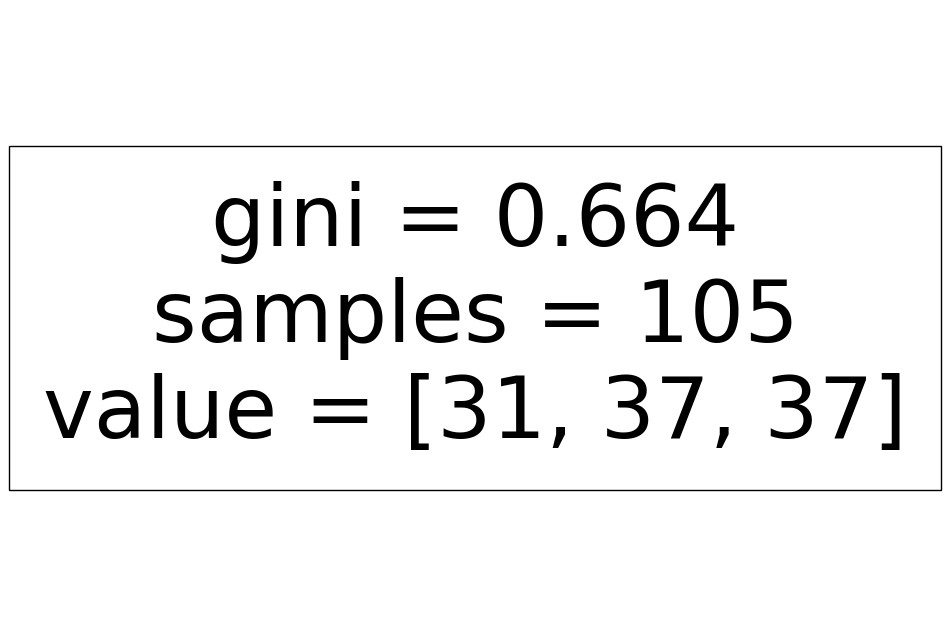

In [1]:

### **Post-pruning का Step-by-Step Example:**


from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Step 1: Load the dataset (Iris dataset)
data = load_iris()
X = data.data
y = data.target

# Step 2: Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 3: Train a full decision tree without pruning (Unpruned tree)
dt_full = DecisionTreeClassifier(random_state=42)
dt_full.fit(X_train, y_train)

# Step 4: Evaluate the full tree on train and test data
print("Full tree score on train data:", dt_full.score(X_train, y_train))
print("Full tree score on test data:", dt_full.score(X_test, y_test))

# Step 5: Apply post-pruning using cost complexity pruning (ccp_alpha)
path = dt_full.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas  # Different alpha values for pruning

# Print the available alpha values to help decide which one to choose
print("Available alpha values:", ccp_alphas)

# Step 6: Choose the best alpha value (here, selecting the largest one for simplicity)
best_alpha = ccp_alphas[-1]  # The last alpha (largest value)

# Step 7: Train a pruned tree using this best alpha value
dt_pruned = DecisionTreeClassifier(random_state=42, ccp_alpha=best_alpha)
dt_pruned.fit(X_train, y_train)

# Step 8: Evaluate the pruned tree on train and test data
print("\nPruned tree score on train data:", dt_pruned.score(X_train, y_train))
print("Pruned tree score on test data:", dt_pruned.score(X_test, y_test))

# Step 9: Visualize the pruned tree
plt.figure(figsize=(12, 8))
plot_tree(dt_pruned, filled=True)
plt.show()




---

### 🔹 **Post-pruning की व्याख्या (Updated):**

1. **Step 1**: पहले हम एक **full decision tree** बनाते हैं (बिना किसी pruning के)।
2. **Step 2**: इस **full tree** की performance को **train** और **test data** पर check करते हैं।
3. **Step 3**: फिर, हम **Cost Complexity Pruning** का path प्राप्त करते हैं, जो हमें अलग-अलग **alpha values** देता है।
4. **Step 4**: अब हम किसी एक **alpha value** का चयन करते हैं जो **tree pruning** को balance करेगा और tree को **simpler** बनाएगा, जिससे **overfitting** कम हो।
5. **Step 5**: इस pruning के बाद, हम pruned tree को **train** करते हैं और उसकी performance को **check** करते हैं।
6. **Step 6**: अंत में, हम pruned tree की **score** को **train** और **test** data पर देखते हैं।

---

### 🔹 **Cost Complexity Pruning (ccp_alpha)** का अर्थ:

**Cost Complexity Pruning (ccp_alpha)** एक **parameter** होता है, जो **tree pruning** को balance करता है:

* जब **alpha (α)** की value बड़ी होती है, तो tree **simpler** और **smaller** हो जाता है, जिससे overfitting कम हो सकता है।
* जब **alpha** की value बहुत छोटी होती है, तो tree अधिक complex हो सकता है, और overfitting का खतरा बढ़ सकता है।
* **Optimal alpha value** को ढूंढने से हम tree को pruning कर सकते हैं, जिससे model **generalize** कर पाए बिना accuracy खोए।

---

### 🔹 **Output:**

* **Full tree** की score (train और test data पर) दिखाएगी।
* **Pruned tree** (ccp_alpha के साथ) की score (train और test data पर) दिखाएगी।
* **Visualization**: Pruned tree की diagram भी दिखाएंगे, जिससे तुम समझ सको कि tree के कितने branches काटे गए हैं।

---

### **Summary**:

* **Pre-pruning**: हम tree को बनने से पहले ही रोकते हैं (जैसे max_depth)।
* **Post-pruning**: पहले tree को fully बनाते हैं, फिर unnecessary branches को काटते हैं (ccp_alpha के साथ)।

अगर तुम **cross-validation** का use करना चाहो तो, तुम **best alpha** चुनने के लिए **validation set** का इस्तेमाल कर सकते हो।

किसी और समस्या या clarification के लिए बताओ! 😊
